# 12 · Clustering, dimension reduction and risk personas (Step 14)

**Goal:** look at the applicants without the label first (segments), then with the model's eyes
(risk personas).

- **A. Segments:** K-means (elbow + silhouette), a Gaussian mixture (BIC), Ward hierarchical
  clustering (dendrogram) and HDBSCAN, on 7 standardised key features. Compared with silhouette,
  Davies–Bouldin, Calinski–Harabasz, agreement (adjusted Rand index) and default rate per cluster.
- **B. Maps:** PCA (scree plot on the building columns; a 2-D map of the key features),
  Fisher LDA (one direction, histogram by class) and t-SNE at three perplexities.
- **C. Risk personas:** cluster the applicants in the decline zone by their **SHAP values**, so
  each group is risky *for the same reasons* (Lundberg et al. 2020, "supervised clustering").

**Data rules:** segments and maps use a 20,000-row sample of the train split. Personas use the
validation split (the model was trained on train, so its SHAP values there would be in-sample).
The test split stays locked until Step 15. Self-training was cut from the plan; reject inference
is discussed in the report.

**Time:** about 3 minutes.

**Saved results:**

- `reports/results_step14_clusters.csv` (method comparison), `results_step14_segments.csv`,
  `results_step14_personas.csv`
- `reports/figures/fig33_cluster_choice.png`, `fig34_dendrogram.png`, `fig35_maps.png`,
  `fig36_risk_personas.png`

In [1]:
%load_ext autoreload
%autoreload 2

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score,
                             roc_auc_score, silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model
from creditrisk.serving.service import feature_label

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

features = load_features()
splits = load_splits()
X_tr, y_tr, _, _ = get_xy(features, splits, "train")
rng = np.random.default_rng(SEED)
rows = np.sort(rng.choice(len(y_tr), 20_000, replace=False))
S, y = X_tr.iloc[rows].reset_index(drop=True), y_tr[rows]

# 7 key features; amounts on a log scale (very skewed), missing years employed = not employed
KEY = {"log income": np.log(S["APP_AMT_INCOME_TOTAL"]),
       "log loan amount": np.log(S["APP_AMT_CREDIT"]),
       "log annuity": np.log(S["APP_AMT_ANNUITY"]),
       "family size": S["APP_CNT_FAM_MEMBERS"],
       "age": S["APP_AGE_YEARS"],
       "years employed": S["APP_EMPLOYED_YEARS"].fillna(0),
       "external score (mean)": S["APP_EXT_MEAN"]}
K = pd.DataFrame(KEY).astype(float)
print("missing values filled with the median:", K.isna().sum()[K.isna().sum() > 0].to_dict())
K = K.fillna(K.median())
Z = StandardScaler().fit_transform(K)
small = np.arange(5_000)               # Ward and HDBSCAN run on the first 5,000 of the sample
print(f"sample: {len(y):,} train applicants, default rate {y.mean():.2%}, {Z.shape[1]} features")

missing values filled with the median: {'log annuity': 1, 'external score (mean)': 13}
sample: 20,000 train applicants, default rate 8.17%, 7 features


## A. Segments

K-means: the elbow in inertia and the silhouette (on 10,000 rows) for k = 2–10. GMM (full
covariances): the lowest BIC. Ward is cut at the K-means k; HDBSCAN chooses its own number of
clusters and marks outliers as noise (−1).

,inertia,silhouette,GMM BIC
k,,,
2,110483.201,0.194,342635.138
3,97355.141,0.175,302197.509
4,87419.627,0.181,298212.885
5,79578.012,0.175,296550.036
6,73511.524,0.169,296276.636
7,69139.486,0.153,295550.437
8,66147.478,0.149,107131.516
9,63373.644,0.149,66690.839
10,61053.281,0.148,107366.638


K-means: best silhouette at k = 2 | GMM: lowest BIC at k = 9


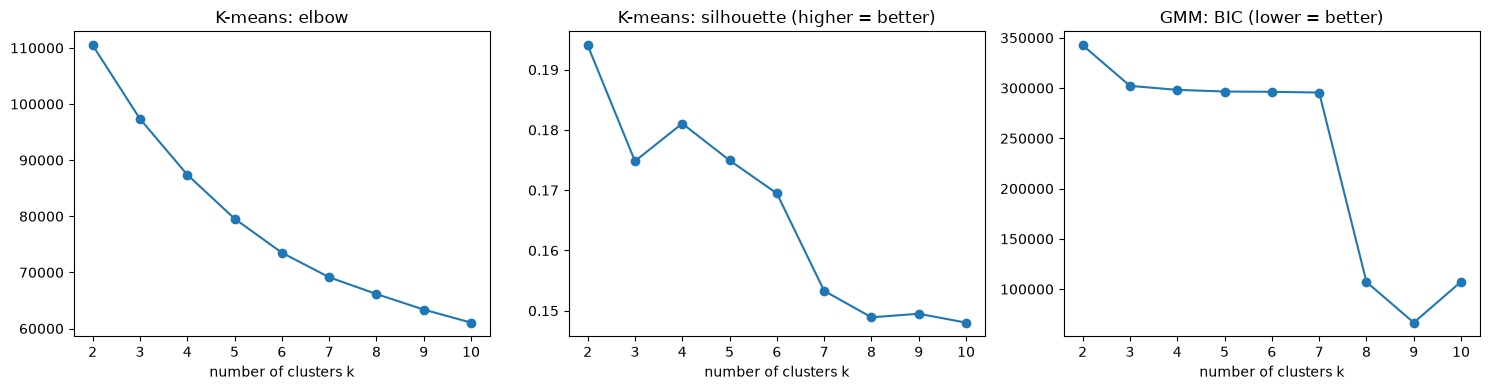

In [2]:
ks = range(2, 11)
choice = []
for k in ks:
    km = KMeans(k, n_init=5, random_state=SEED).fit(Z)
    gmm = GaussianMixture(k, n_init=2, random_state=SEED).fit(Z)
    choice.append({"k": k, "inertia": km.inertia_,
                   "silhouette": silhouette_score(Z, km.labels_, sample_size=10_000,
                                                  random_state=SEED),
                   "GMM BIC": gmm.bic(Z)})
choice = pd.DataFrame(choice).set_index("k")
k_best = int(choice["silhouette"].idxmax())
k_gmm = int(choice["GMM BIC"].idxmin())
display(choice.round(3))
print(f"K-means: best silhouette at k = {k_best} | GMM: lowest BIC at k = {k_gmm}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, choice.columns, strict=True):
    ax.plot(choice.index, choice[col], "o-")
    ax.set(title={"inertia": "K-means: elbow", "silhouette": "K-means: silhouette (higher = better)",
                  "GMM BIC": "GMM: BIC (lower = better)"}[col], xlabel="number of clusters k")
fig.tight_layout()
fig.savefig(FIG / "fig33_cluster_choice.png", dpi=150)
plt.show()
facts["k"] = {"kmeans_silhouette": k_best, "gmm_bic": k_gmm}

In [3]:
gmm = GaussianMixture(k_gmm, n_init=2, random_state=SEED).fit(Z)
labels = {"K-means": KMeans(k_best, n_init=10, random_state=SEED).fit_predict(Z),
          "GMM": gmm.predict(Z)}
# a component with ~0 variance on a feature sits on one exact value (a point mass)
spread = pd.DataFrame([np.diag(c) for c in gmm.covariances_], columns=K.columns)
print("GMM components with variance < 0.001, per feature:", (spread < 1e-3).sum().to_dict())
ward = AgglomerativeClustering(k_best, linkage="ward").fit_predict(Z[small])
hdb = HDBSCAN(min_cluster_size=100, min_samples=5, copy=True).fit_predict(Z[small])  # default min_samples: all noise


def default_spread(lab, yy):
    """Default rate of the riskiest and safest cluster (noise and clusters < 50 left out)."""
    rates = pd.Series(yy).groupby(lab).agg(["mean", "size"])
    rates = rates[(rates.index != -1) & (rates["size"] >= 50)]["mean"]
    return rates.min(), rates.max()


table = {}
small_labels = {"K-means": labels["K-means"][small], "GMM": labels["GMM"][small],
                "Ward": ward, "HDBSCAN": hdb}
for name, lab in small_labels.items():
    keep = lab != -1                                  # HDBSCAN noise is not a cluster
    lo, hi = default_spread(lab, y[small])
    table[name] = {"clusters": len(set(lab[keep])), "noise share": np.mean(~keep),
                   "silhouette": silhouette_score(Z[small][keep], lab[keep]),
                   "Davies-Bouldin (lower = better)": davies_bouldin_score(Z[small][keep], lab[keep]),
                   "Calinski-Harabasz": calinski_harabasz_score(Z[small][keep], lab[keep]),
                   "ARI vs K-means": adjusted_rand_score(small_labels["K-means"], lab),
                   "lowest default rate": lo, "highest default rate": hi,
                   # how well "the default rate of my cluster" ranks risk, vs 0.79 for the model
                   "ROC-AUC of cluster default rate": roc_auc_score(
                       y[small], pd.Series(y[small]).groupby(lab).transform("mean"))}
clusters = pd.DataFrame(table).T
display(clusters.astype(float).round(3))
clusters.to_csv(REPORTS / "results_step14_clusters.csv")
facts["clusters"] = clusters.astype(float).round(3).to_dict(orient="index")
noise = hdb == -1
print(f"HDBSCAN noise: {noise.mean():.1%} of rows, default rate {y[small][noise].mean():.2%} "
      f"vs {y[small][~noise].mean():.2%} for the rest")

GMM components with variance < 0.001, per feature: {'log income': 0, 'log loan amount': 0, 'log annuity': 0, 'family size': 8, 'age': 0, 'years employed': 2, 'external score (mean)': 0}


,clusters,noise share,silhouette,Davies-Bouldin (lower = better),Calinski-Harabasz,ARI vs K-means,lowest default rate,highest default rate,ROC-AUC of cluster default rate
K-means,2.0,0.000,0.195,1.824,1361.302,1.000,0.084,0.088,0.505
GMM,9.0,0.000,0.025,3.425,204.459,0.014,0.054,0.116,0.552
Ward,2.0,0.000,0.153,2.086,1038.007,0.515,0.085,0.087,0.504
HDBSCAN,4.0,0.202,0.043,3.292,273.905,0.007,0.080,0.109,0.523


HDBSCAN noise: 20.2% of rows, default rate 9.12% vs 8.47% for the rest


**The K-means segments,** described by the mean of each key feature (original units) and named by
what stands out.

,share,family size,age,years employed,external score (mean),income,loan amount,annuity,default rate
0,0.548,2.24,43.76,6.41,0.53,208866.84,846534.43,36163.80,0.076
1,0.452,2.03,43.93,4.12,0.48,120916.74,298463.97,16351.51,0.089


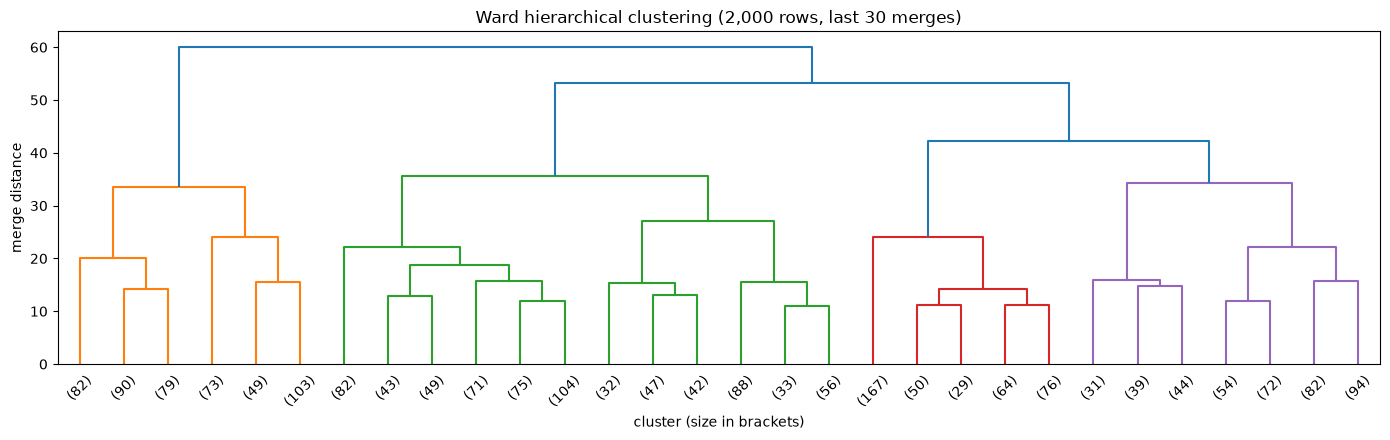

In [4]:
seg = K.assign(**{"income": np.exp(K["log income"]), "loan amount": np.exp(K["log loan amount"]),
                  "annuity": np.exp(K["log annuity"])}).drop(
    columns=["log income", "log loan amount", "log annuity"])
segments = seg.groupby(labels["K-means"]).mean().round(2)
segments.insert(0, "share", pd.Series(labels["K-means"]).value_counts(normalize=True).sort_index())
segments["default rate"] = pd.Series(y).groupby(labels["K-means"]).mean()
segments = segments.sort_values("default rate")
display(segments.round(3))
segments.to_csv(REPORTS / "results_step14_segments.csv")
facts["segments"] = segments.round(3).to_dict(orient="index")

fig, ax = plt.subplots(figsize=(14, 4.5))
Zw = Z[small][:2_000]                     # 2,000 rows keep the tree readable
dendrogram(linkage(Zw, method="ward"), truncate_mode="lastp", p=30, ax=ax,
           color_threshold=None, no_labels=False)
ax.set(title="Ward hierarchical clustering (2,000 rows, last 30 merges)",
       xlabel="cluster (size in brackets)", ylabel="merge distance")
fig.tight_layout()
fig.savefig(FIG / "fig34_dendrogram.png", dpi=150)
plt.show()

## B. Maps

- **PCA scree** on the numeric building-description columns (`_AVG` / `_MODE` / `_MEDI`
  triples, rows with all of them present): how many directions do they really need?
- **PCA 2-D** of the 7 key features, coloured by K-means segment.
- **Fisher LDA:** the one direction that best separates defaulters from repayers.
- **t-SNE** on 5,000 rows at perplexity 5, 30 and 100, coloured by default. Gaps and cluster
  sizes in t-SNE carry no meaning; only who is near whom does.

building block: 43 columns, 5,284 complete rows; 8 components keep 90% of the variance
PCA on the key features: 2 components keep 52.6%
LDA direction: ROC-AUC 0.714; weights {'log income': np.float64(-0.07), 'log loan amount': np.float64(-0.06), 'log annuity': np.float64(0.22), 'family size': np.float64(0.03), 'age': np.float64(-0.03), 'years employed': np.float64(-0.06), 'external score (mean)': np.float64(-1.01)}


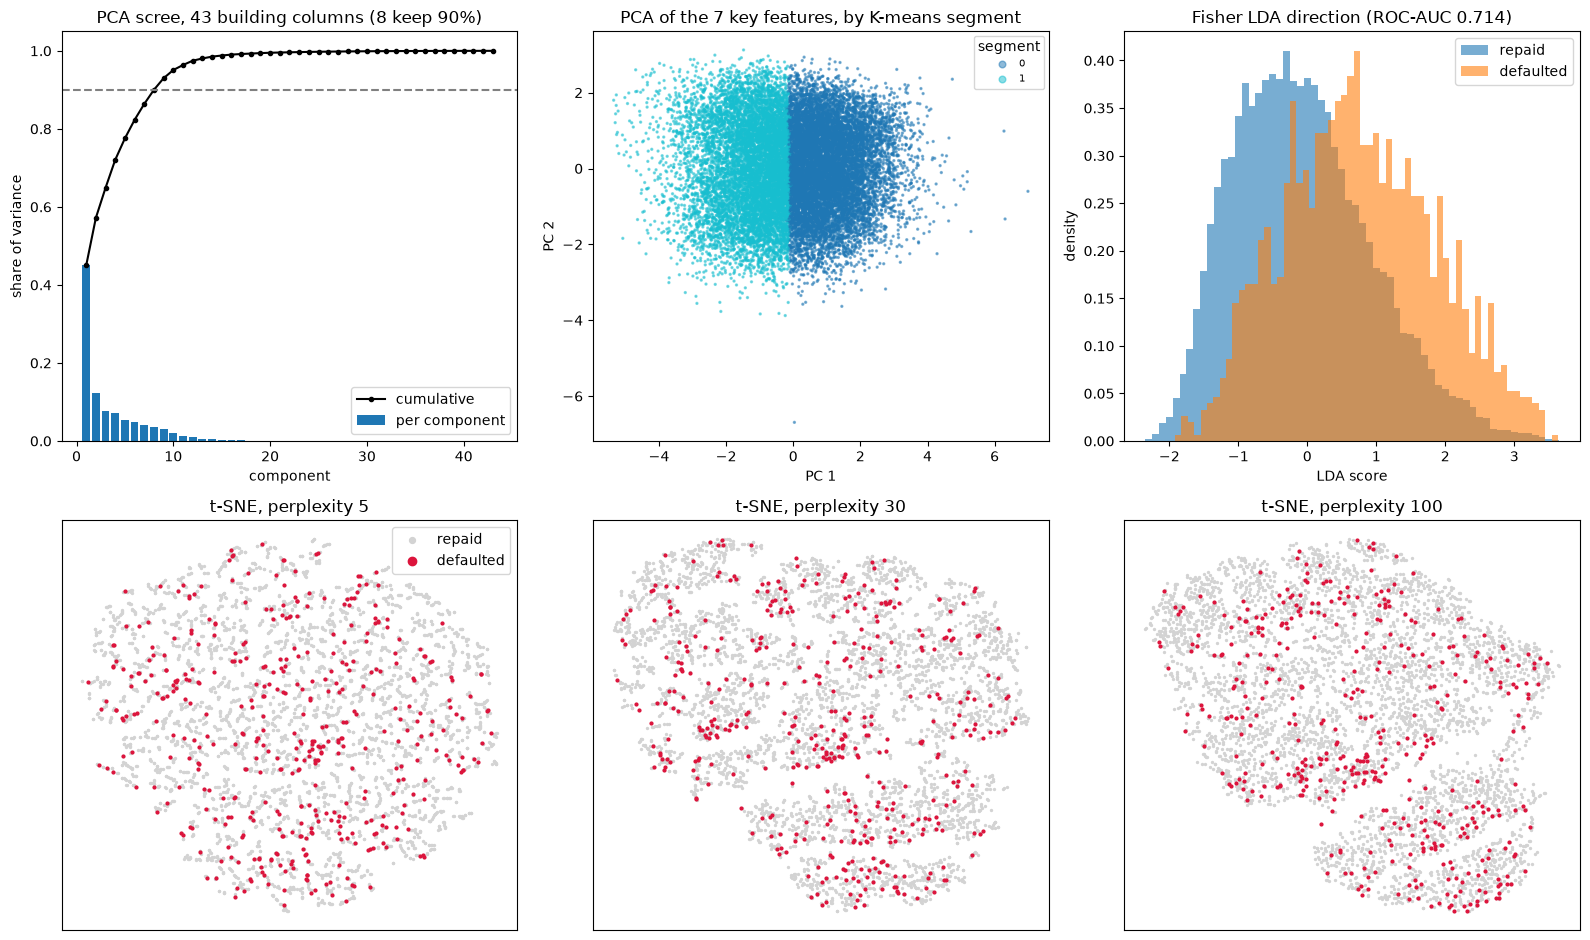

In [5]:
building = [c for c in X_tr.columns if c.endswith(("_AVG", "_MODE", "_MEDI"))
            and pd.api.types.is_numeric_dtype(X_tr[c])]          # 4 _MODE columns are text
B = S[building].dropna()
pca_b = PCA().fit(StandardScaler().fit_transform(B))
cum = np.cumsum(pca_b.explained_variance_ratio_)
n90 = int(np.searchsorted(cum, 0.90) + 1)
print(f"building block: {len(building)} columns, {len(B):,} complete rows; "
      f"{n90} components keep 90% of the variance")

pca_k = PCA(2).fit(Z)
P = pca_k.transform(Z)
lda = LinearDiscriminantAnalysis().fit(Z, y)
L = lda.transform(Z)[:, 0]
auc_lda = roc_auc_score(y, L)
print(f"PCA on the key features: 2 components keep {pca_k.explained_variance_ratio_.sum():.1%}")
print(f"LDA direction: ROC-AUC {auc_lda:.3f}; weights "
      f"{dict(zip(K.columns, lda.scalings_[:, 0].round(2), strict=True))}")
facts["maps"] = {"building_components_90": n90, "building_rows": len(B),
                 "pca2_variance": round(float(pca_k.explained_variance_ratio_.sum()), 3),
                 "lda_auc": round(auc_lda, 3)}

tsne_rows = small
emb = {perp: TSNE(perplexity=perp, random_state=SEED, init="pca").fit_transform(Z[tsne_rows])
       for perp in (5, 30, 100)}

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
ax = axes[0, 0]
ax.bar(range(1, len(cum) + 1), pca_b.explained_variance_ratio_, label="per component")
ax.plot(range(1, len(cum) + 1), cum, "k.-", label="cumulative")
ax.axhline(0.9, color="grey", ls="--")
ax.set(title=f"PCA scree, {len(building)} building columns ({n90} keep 90%)", xlabel="component",
       ylabel="share of variance")
ax.legend()
ax = axes[0, 1]
sc = ax.scatter(P[:, 0], P[:, 1], c=labels["K-means"], s=2, cmap="tab10", alpha=0.5)
ax.set(title="PCA of the 7 key features, by K-means segment", xlabel="PC 1", ylabel="PC 2")
ax.legend(*sc.legend_elements(), title="segment", fontsize=7, markerscale=0.8)
ax = axes[0, 2]
for cls, name in [(0, "repaid"), (1, "defaulted")]:
    ax.hist(L[y == cls], bins=60, density=True, alpha=0.6, label=name)
ax.set(title=f"Fisher LDA direction (ROC-AUC {auc_lda:.3f})", xlabel="LDA score",
       ylabel="density")
ax.legend()
for ax, (perp, E) in zip(axes[1], emb.items(), strict=True):
    yy = y[tsne_rows]
    ax.scatter(E[yy == 0, 0], E[yy == 0, 1], s=2, c="lightgrey", label="repaid")
    ax.scatter(E[yy == 1, 0], E[yy == 1, 1], s=4, c="crimson", label="defaulted")
    ax.set(title=f"t-SNE, perplexity {perp}", xticks=[], yticks=[])
axes[1, 0].legend(markerscale=3)
fig.tight_layout()
fig.savefig(FIG / "fig35_maps.png", dpi=150)
plt.show()

## C. Risk personas in SHAP space

The applicants the model would decline (Step 11's decline zone, p above the conformal cut-off) on
the validation split. Each is described by its 240 SHAP values (log-odds pushes). K-means on these
vectors groups people who are risky *for the same reasons*. Each persona is named after its
largest average pushes.

In [6]:
model, details = load_final_model()
model = joblib.load(MODEL_DIR / "calibrated_final.joblib")
decline_above = json.loads((MODEL_DIR / "decision.json").read_text())["conformal"]["decline_above"]
X_val, y_val, _, _ = get_xy(features, splits, "valid")
X_val = X_val[details["features"]]
p_val = model.predict_proba(X_val)[:, 1]
risky = p_val > decline_above
shap = model.predict(X_val[risky], pred_contrib=True)[:, :-1]      # TreeSHAP, drop the bias
print(f"decline zone: {risky.sum():,} applicants, default rate {y_val[risky].mean():.2%}")

persona_choice = {k: silhouette_score(shap, KMeans(k, n_init=10, random_state=SEED).fit_predict(shap))
                  for k in range(2, 9)}
k_p = max(persona_choice, key=persona_choice.get)
print("silhouette by k:", {k: round(v, 3) for k, v in persona_choice.items()}, "-> k =", k_p)
persona = KMeans(k_p, n_init=10, random_state=SEED).fit_predict(shap)

mean_shap = pd.DataFrame(shap, columns=details["features"]).groupby(persona).mean()
rows_p = []
for c in range(k_p):
    top = mean_shap.loc[c].nlargest(3)
    rows_p.append({"persona": c, "applicants": int(np.sum(persona == c)),
                   "default rate": y_val[risky][persona == c].mean(),
                   "mean predicted": p_val[risky][persona == c].mean(),
                   "top reasons (mean SHAP)": "; ".join(f"{feature_label(f)} (+{v:.2f})"
                                                       for f, v in top.items())})
personas = pd.DataFrame(rows_p).set_index("persona").sort_values("default rate", ascending=False)
pd.set_option("display.max_colwidth", 200)
display(personas.round(3))
personas.to_csv(REPORTS / "results_step14_personas.csv")
facts["personas"] = personas.round(3).to_dict(orient="index")

decline zone: 3,897 applicants, default rate 28.56%


silhouette by k: {2: 0.095, 3: 0.099, 4: 0.099, 5: 0.081, 6: 0.071, 7: 0.064, 8: 0.06} -> k = 3


,applicants,default rate,mean predicted,top reasons (mean SHAP)
persona,,,,
1,1637,0.310,0.309,External credit scores (average) (+0.42); External credit scores (lowest) (+0.31); External credit scores (highest) (+0.24)
0,652,0.301,0.294,Credit cards: util latest mean (+0.37); External credit scores (average) (+0.22); External credit scores (highest) (+0.16)
2,1608,0.254,0.246,External credit scores (average) (+0.19); External credit scores (highest) (+0.13); Annuity ÷ loan amount (repayment speed) (+0.10)


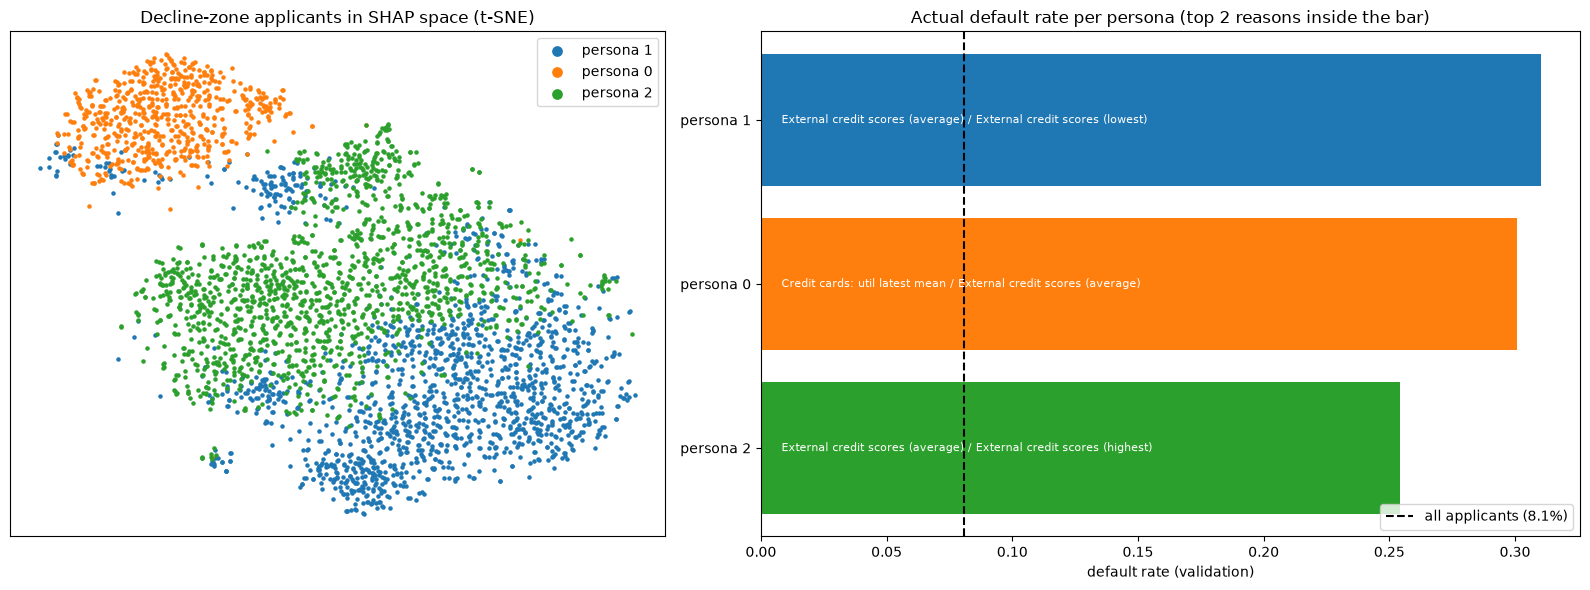

In [7]:
E = TSNE(perplexity=30, random_state=SEED, init="pca").fit_transform(shap)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
for c in personas.index:
    m = persona == c
    ax.scatter(E[m, 0], E[m, 1], s=5, label=f"persona {c}")
ax.set(title="Decline-zone applicants in SHAP space (t-SNE)", xticks=[], yticks=[])
ax.legend(markerscale=3)
ax = axes[1]
order = personas.index[::-1]
ax.barh([f"persona {c}" for c in order], personas.loc[order, "default rate"],
        color=[f"C{list(personas.index).index(c)}" for c in order])
for i, c in enumerate(order):
    reasons = personas.loc[c, "top reasons (mean SHAP)"].split("; ")[:2]
    ax.text(0.005, i, "  " + " / ".join(r.rsplit(" (", 1)[0] for r in reasons), va="center",
            fontsize=8, color="white")
ax.axvline(y_val.mean(), color="k", ls="--", label=f"all applicants ({y_val.mean():.1%})")
ax.set(title="Actual default rate per persona (top 2 reasons inside the bar)",
       xlabel="default rate (validation)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "fig36_risk_personas.png", dpi=150)
plt.show()

In [8]:
for key, value in facts.items():
    print(f"{key}: {value}")

k: {'kmeans_silhouette': 2, 'gmm_bic': 9}
clusters: {'K-means': {'clusters': 2.0, 'noise share': 0.0, 'silhouette': 0.195, 'Davies-Bouldin (lower = better)': 1.824, 'Calinski-Harabasz': 1361.302, 'ARI vs K-means': 1.0, 'lowest default rate': 0.084, 'highest default rate': 0.088, 'ROC-AUC of cluster default rate': 0.505}, 'GMM': {'clusters': 9.0, 'noise share': 0.0, 'silhouette': 0.025, 'Davies-Bouldin (lower = better)': 3.425, 'Calinski-Harabasz': 204.459, 'ARI vs K-means': 0.014, 'lowest default rate': 0.054, 'highest default rate': 0.116, 'ROC-AUC of cluster default rate': 0.552}, 'Ward': {'clusters': 2.0, 'noise share': 0.0, 'silhouette': 0.153, 'Davies-Bouldin (lower = better)': 2.086, 'Calinski-Harabasz': 1038.007, 'ARI vs K-means': 0.515, 'lowest default rate': 0.085, 'highest default rate': 0.087, 'ROC-AUC of cluster default rate': 0.504}, 'HDBSCAN': {'clusters': 4.0, 'noise share': 0.202, 'silhouette': 0.043, 'Davies-Bouldin (lower = better)': 3.292, 'Calinski-Harabasz': 273.90

## Findings

- **The applicants form one blob, not natural groups.** The best K-means silhouette is only 0.19 (k = 2) and falls as k grows. The two segments split by loan size: larger loans (income 209k, loan 847k) vs smaller (121k, 298k). Ward agrees only partly (ARI 0.52). HDBSCAN needed `min_samples=5` to find anything at all (with the default it calls every point noise); it finds 4 dense pockets and leaves 20% as noise.
- **Segments carry almost no risk signal:** the two K-means segments default at 7.6% and 8.9%. Using "the default rate of my cluster" as a score gives ROC-AUC 0.50–0.55 for every method, vs 0.79 for the model. Structure in the inputs is not structure in the risk. Segmentation is useful for describing customers, not for scoring them.
- **BIC can be fooled:** the GMM's BIC drops sharply at k = 8–9, but the extra components sit on exact values (zero variance in family size, which takes whole numbers, and in "years employed = 0"). These point masses have unbounded likelihood, so BIC rewards them. Its silhouette (0.025) shows the clusters are not real. Discrete features need jitter or a different model before a GMM.
- **PCA:** the 43 numeric building columns (the `_AVG / _MODE / _MEDI` triples) need only 8 components for 90% of the variance (the first alone holds 45%). This confirms the 64 near-duplicate pairs found in the EDA. On the 7 key features, 2 components keep 53%.
- **Fisher LDA:** one linear direction of the 7 key features reaches ROC-AUC 0.714, almost entirely from the external score (weight −1.01) and the annuity (+0.22).
- **t-SNE:** at perplexities 5, 30 and 100, defaulters are spread through the whole map with no separate island. Perplexity changes the shape (more, smaller blobs at 5), which is why one t-SNE picture should not be read as clusters.
- **Risk personas (SHAP space, 3,897 decline-zone applicants on validation, 28.6% default):** K-means with k = 3 (silhouette 0.099, a soft structure). Each persona's mean predicted risk matches its actual default rate within 0.8 points.
  - **"Low external scores"** (1,637 applicants, 31.0% default): all three external scores are low, and they dominate.
  - **"Maxed-out credit card"** (652, 30.1%): high recent credit-card utilisation is the top reason. This is the clearest island in the SHAP map, and it is also actionable (pay the card down).
  - **"Borderline, mixed reasons"** (1,608, 25.4%): weaker external-score pushes plus repayment speed (annuity ÷ loan amount).
- **Why this matters:** the same 28.6% average hides different stories. A reviewer in the refer / decline queue can be told which persona an applicant belongs to, and the persona says what to look at (the bureau, the card, or the loan size).
- **Not done (cut from the plan):** self-training on the 48,744 unlabelled applications. Reject inference is discussed in the report instead.